<a href="https://colab.research.google.com/github/DawiSyauqi/2311532009_MuhammadDawiSyauqi_ImageProcessing/blob/main/Tugas_Fourier_Transform_Muhammad_Dawi_Syauqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

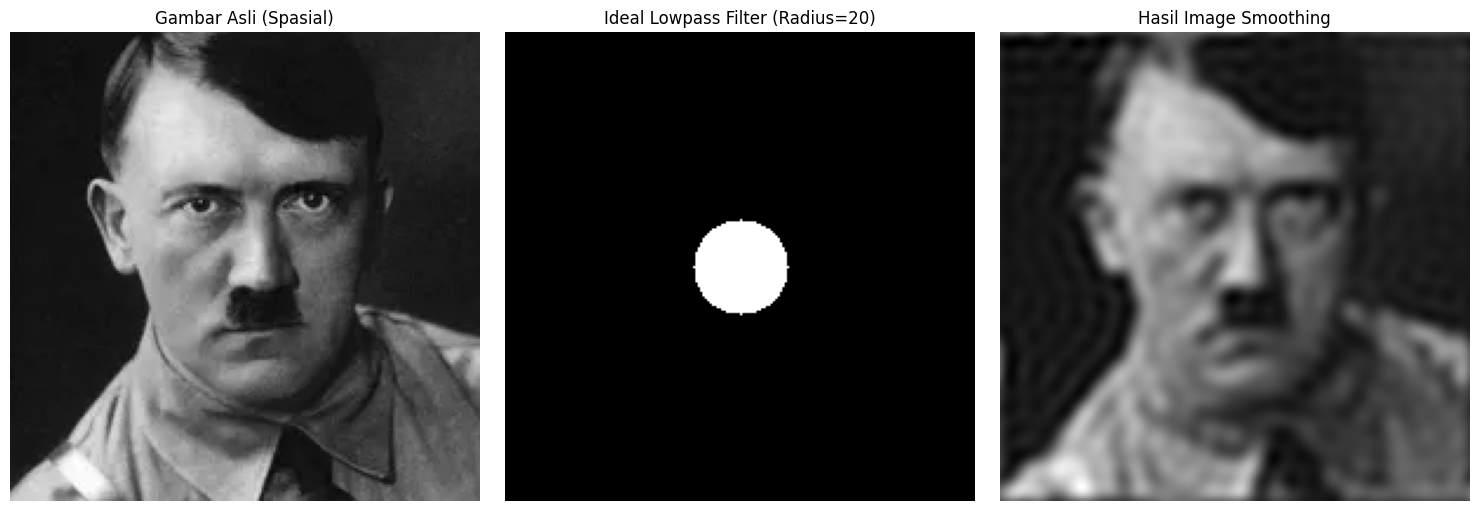

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca gambar dalam format Grayscale (hitam putih)
# Pastikan Anda memiliki file gambar bernama 'gambar_test.jpg' di folder yang sama
image = cv2.imread('/content/Adolf-Hitler-1933.webp', cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Gambar tidak ditemukan! Pastikan path/nama file benar.")
else:
    # ==========================================
    # TAHAP 1: Transformasi ke Domain Frekuensi
    # ==========================================
    # Melakukan Fast Fourier Transform 2D
    f_transform = np.fft.fft2(image)

    # Menggeser frekuensi nol (DC component) ke tengah matriks
    # Jika tidak digeser, frekuensi rendah akan berada di pojok-pojok matriks
    f_shift = np.fft.fftshift(f_transform)

    # Menghitung magnitude spectrum hanya untuk visualisasi plot (opsional)
    magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)

    # ==========================================
    # TAHAP 2: Membuat & Mengaplikasikan Filter
    # ==========================================
    # Mendapatkan ukuran dimensi gambar
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2  # Mencari titik tengah matriks

    # Membuat mask (matriks penyaring) Ideal Lowpass Filter
    # Diisi dengan 0 (hitam/diblokir), lalu kita buat lingkaran 1 (putih/dilewatkan) di tengah
    mask = np.zeros((rows, cols), np.uint8)
    r = 20  # Radius lingkaran (semakin kecil radius, semakin blur gambarnya)

    # Menggambar lingkaran putih (nilai 1) di tengah mask
    center = [crow, ccol]
    x, y = np.ogrid[:rows, :cols]
    mask_area = (x - center[0])**2 + (y - center[1])**2 <= r*r
    mask[mask_area] = 1

    # Mengalikan spektrum frekuensi gambar dengan mask (filtering element-wise)
    f_shift_filtered = f_shift * mask

    # ==========================================
    # TAHAP 3: Inverse Transform (Kembali ke Gambar Asli)
    # ==========================================
    # Menggeser kembali matriks frekuensi dari tengah ke pojok
    f_ishift = np.fft.ifftshift(f_shift_filtered)

    # Melakukan Inverse Fast Fourier Transform 2D
    img_back = np.fft.ifft2(f_ishift)

    # Mengambil nilai absolut/nyata dari bilangan kompleks hasil inversi
    img_back = np.abs(img_back)

    # ==========================================
    # Visualisasi Hasil
    # ==========================================
    plt.figure(figsize=(15, 5))

    plt.subplot(131)
    plt.imshow(image, cmap='gray')
    plt.title('Gambar Asli (Spasial)'), plt.axis('off')

    plt.subplot(132)
    # Visualisasi mask filter (opsional, agar terlihat area yang dilewatkan)
    plt.imshow(mask, cmap='gray')
    plt.title(f'Ideal Lowpass Filter (Radius={r})'), plt.axis('off')

    plt.subplot(133)
    plt.imshow(img_back, cmap='gray')
    plt.title('Hasil Image Smoothing'), plt.axis('off')

    plt.tight_layout()
    plt.show()